# COMP5318 Assignment 1: Rice Classification

##### Group number: 131
##### Student Xiqing Hou SID: 530744007
##### Student Emma Shan SID: 530515599  
##### Student Runda Weng SID: 540917343 
##### Student Tingyi Lu SID: 560299003

## **1. Data Pre-processing**

In [4]:
# Import all libraries
from sklearn.model_selection import StratifiedKFold

In [5]:
# Ignore future warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [6]:
# Load the rice dataset: rice-final2.csv
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('rice-final2.csv')

In [7]:
# Pre-process dataset
# -------------------------------------------------------
# 1. Filling in the missing attribute values
# -------------------------------------------------------
df.replace('?', np.nan, inplace=True)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = X.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)

# -------------------------------------------------------
# 2. Normalising the data
# -------------------------------------------------------

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_imputed)

# -------------------------------------------------------
# 3. Chaning the class values
# -------------------------------------------------------

class_mapping = {'class1': 0, 'class2': 1}
y_mapped_array = y.map(class_mapping).astype(int).values

In [8]:
# Print first ten rows of pre-processed dataset to 4 decimal places as per assignment spec
# A function is provided to assist

def print_data(X, y, n_rows=10):
    """Takes a numpy data array and target and prints the first ten rows.
    
    Arguments:
        X: numpy array of shape (n_examples, n_features)
        y: numpy array of shape (n_examples)
        n_rows: numpy of rows to print
    """
    for example_num in range(n_rows):
        for feature in X[example_num]:
            print("{:.4f}".format(feature), end=",")

        if example_num == len(X)-1:
            print(y[example_num],end="")
        else:
            print(y[example_num])
            
print_data(X_normalized, y_mapped_array, n_rows=10)

0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


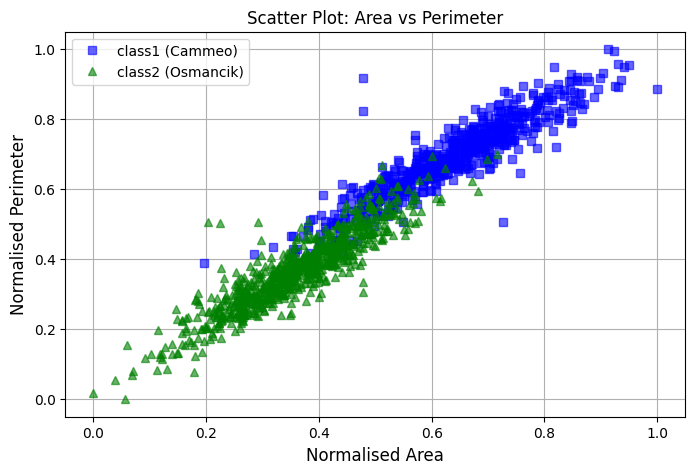

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

#  class 0 as blue squares
plt.plot(X_normalized[:, 0][y_mapped_array==0], X_normalized[:, 1][y_mapped_array==0], "bs", label="class1 (Cammeo)", alpha=0.6)
#  class 1 as green triangles
plt.plot(X_normalized[:, 0][y_mapped_array==1], X_normalized[:, 1][y_mapped_array==1], "g^", label="class2 (Osmancik)", alpha=0.6)

plt.xlabel("Normalised Area", fontsize=12)
plt.ylabel("Normalised Perimeter", fontsize=12)
plt.legend()
plt.title("Scatter Plot: Area vs Perimeter")
plt.grid(True)
plt.show()

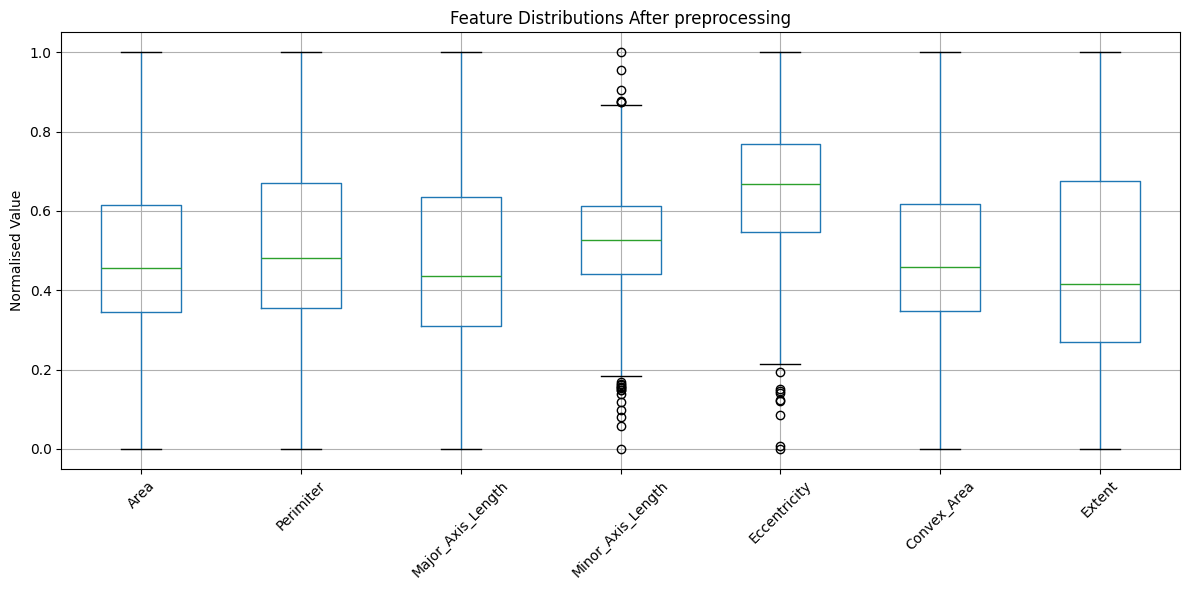

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# a dataframe from the processed feature matrix
feature_names = df.columns[:-1]
feature_df = pd.DataFrame(X_normalized, columns=feature_names)

plt.figure(figsize=(12, 6))
feature_df.boxplot(rot=45)
plt.title("Feature Distributions After preprocessing")
plt.ylabel("Normalised Value")
plt.tight_layout()
plt.show()

The boxplot above will show the spreads of all features after a min/max normalisation. The features will have been rescaled to the interval of [0,1] and be on a compariable scale for distance based methods. 

## **2. Build Classifiers**

- Part 1:  Logistic Regression, Naïve Bayes
- Part 2:  KNN, Decision Tree, Ada Boost, Gradient Boost, Random Forest, SVM

### Part 1: Cross-validation without parameter tuning

In [11]:
## Setting the 10 fold stratified cross-validation
cvKFold=StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# The stratified folds from cvKFold should be provided to the classifiers

In [12]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(random_state=0)

log_reg_scores = cross_val_score(log_reg, X_normalized, y_mapped_array, cv=cvKFold, scoring='accuracy')

In [13]:
# Naïve Bayes
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

nb_scores = cross_val_score(naive_bayes, X_normalized, y_mapped_array, cv=cvKFold, scoring='accuracy')


### Part 1 Results


In [14]:
# Print results for each classifier in part 1 to 4 decimal places here:
print(f"LogR average cross-validation accuracy: {log_reg_scores.mean():.4f}")
print(f"NB average cross-validation accuracy: {nb_scores.mean():.4f}")

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


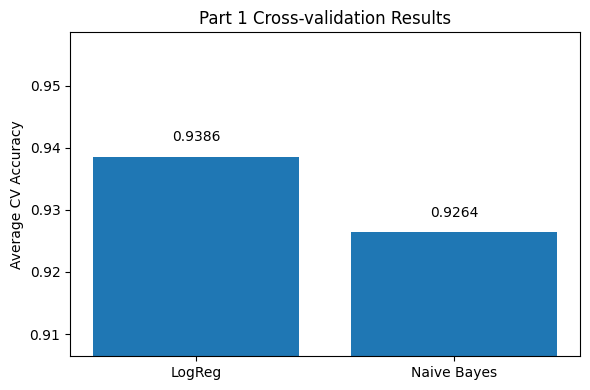

In [15]:
# classifier comparison
import matplotlib.pyplot as plt

models_part1 = ["LogReg", "Naive Bayes"]
acc_part1 = [log_reg_scores.mean(), nb_scores.mean()]

plt.figure(figsize=(6, 4))
bars = plt.bar(models_part1, acc_part1)

plt.ylabel("Average CV Accuracy")
plt.title("Part 1 Cross-validation Results")


ymin = min(acc_part1) - 0.02
ymax = max(acc_part1) + 0.02
plt.ylim(ymin, ymax)

for bar, val in zip(bars, acc_part1):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Part 2: Cross-validation with parameter tuning

In [16]:
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# Train/Test Split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y_mapped_array,
    test_size=0.2,
    stratify=y_mapped_array,
    random_state=0
)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
# KNN 
# parameters you may consider
# k = [1, 3, 5, 7]
# p = [1, 2]
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7],
    'p': [1, 2]
}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# perform Grid Search with 10-fold stratified cross-validation
grid_search_knn = GridSearchCV(estimator=knn,
                               param_grid=param_grid_knn,
                               cv=cvKFold,
                               scoring='accuracy')

# Fit the grid search model exclusively on the training data
grid_search_knn.fit(X_train, y_train)

# Retrieve the best parameters and the best cross-validation accuracy
best_k = grid_search_knn.best_params_['n_neighbors']
best_p = grid_search_knn.best_params_['p']
cv_accuracy = grid_search_knn.best_score_

best_knn_model = grid_search_knn.best_estimator_
test_accuracy = best_knn_model.score(X_test, y_test)

print(f"KNN best k: {best_k}")
print(f"KNN best p: {best_p}")
print(f"KNN cross-validation accuracy: {cv_accuracy:.4f}")
print(f"KNN test set accuracy: {test_accuracy:.4f}")

KNN best k: 7
KNN best p: 2
KNN cross-validation accuracy: 0.9375
KNN test set accuracy: 0.9250


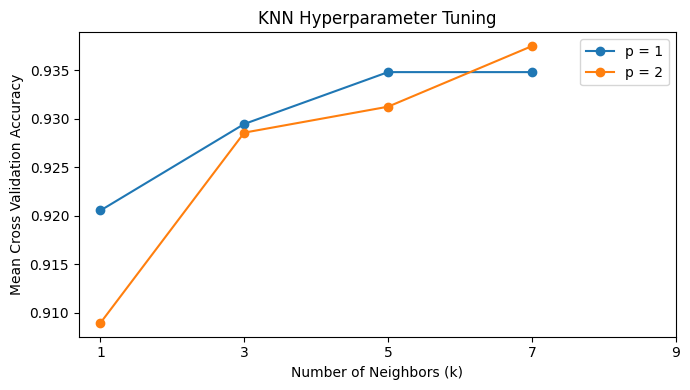

In [18]:
# graph for KNN hyperparameter tuning
import pandas as pd
import matplotlib.pyplot as plt

knn_results = pd.DataFrame(grid_search_knn.cv_results_)

p1_results = knn_results[knn_results["param_p"] == 1]
p2_results = knn_results[knn_results["param_p"] == 2]

plt.figure(figsize=(7, 4))
plt.plot(p1_results["param_n_neighbors"], p1_results["mean_test_score"], marker="o", label="p = 1")
plt.plot(p2_results["param_n_neighbors"], p2_results["mean_test_score"], marker="o", label="p = 2")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("KNN Hyperparameter Tuning")
plt.xticks([1, 3, 5, 7, 9])
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree 
# parameters you may consider
# max_depth = [3, 5, 7, 10]
# min_samples_split = [2, 5, 10]
# min_samples_leaf = [1, 2, 4]
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=0)

grid_search_dt = GridSearchCV(estimator=dt,
                              param_grid=param_grid_dt,
                              cv=cvKFold,
                              scoring='accuracy')

grid_search_dt.fit(X_train, y_train)

best_depth = grid_search_dt.best_params_['max_depth']
best_min_samples_split = grid_search_dt.best_params_['min_samples_split']
best_min_samples_leaf = grid_search_dt.best_params_['min_samples_leaf']
cv_accuracy_dt = grid_search_dt.best_score_

best_dt_model = grid_search_dt.best_estimator_
test_accuracy_dt = best_dt_model.score(X_test, y_test)

print(f"Decision Tree best max_depth: {best_depth}")
print(f"Decision Tree best min_samples_split: {best_min_samples_split}")
print(f"Decision Tree best min_samples_leaf: {best_min_samples_leaf}")
print(f"Decision Tree cross-validation accuracy: {cv_accuracy_dt:.4f}")
print(f"Decision Tree test set accuracy: {test_accuracy_dt:.4f}")

Decision Tree best max_depth: 3
Decision Tree best min_samples_split: 2
Decision Tree best min_samples_leaf: 1
Decision Tree cross-validation accuracy: 0.9357
Decision Tree test set accuracy: 0.9429


In [20]:
from sklearn.ensemble import AdaBoostClassifier
# Ada Boost
# parameters you may consider
# n_estimators = [50, 100, 150]
# learning_rate = [0.1, 0.2, 0.3, 0.5]

param_grid_ada = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3, 0.5]
}

ada = AdaBoostClassifier(random_state=0)

grid_search_ada = GridSearchCV(estimator=ada,
                               param_grid=param_grid_ada,
                               cv=cvKFold,
                               scoring='accuracy')

grid_search_ada.fit(X_train, y_train)

best_n_estimators = grid_search_ada.best_params_['n_estimators']
best_learning_rate = grid_search_ada.best_params_['learning_rate']
cv_accuracy_ada = grid_search_ada.best_score_

best_ada_model = grid_search_ada.best_estimator_
test_accuracy_ada = best_ada_model.score(X_test, y_test)

print(f"Ada Boost best n_estimators: {best_n_estimators}")
print(f"Ada Boost best learning_rate: {best_learning_rate}")
print(f"Ada Boost cross-validation accuracy: {cv_accuracy_ada:.4f}")
print(f"Ada Boost test set accuracy: {test_accuracy_ada:.4f}")

Ada Boost best n_estimators: 100
Ada Boost best learning_rate: 0.1
Ada Boost cross-validation accuracy: 0.9437
Ada Boost test set accuracy: 0.9393


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
# Gradient Boost
# parameters you may consider
# max_depth = [1, 3, 5, 7]
# n_estimators = [50, 100, 150]
# learning_rate = [0.1, 0.2, 0.3, 0.5]

param_grid_gb = {
    'max_depth': [1, 3, 5, 7],
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3, 0.5]
}

gb = GradientBoostingClassifier(random_state=0)

grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

best_depth_gb = grid_search_gb.best_params_['max_depth']
best_n_estimators_gb = grid_search_gb.best_params_['n_estimators']
best_learning_rate_gb = grid_search_gb.best_params_['learning_rate']
cv_accuracy_gb = grid_search_gb.best_score_

best_gb_model = grid_search_gb.best_estimator_
test_accuracy_gb = best_gb_model.score(X_test, y_test)

print(f"Gradient Boost best max_depth: {best_depth_gb}")
print(f"Gradient Boost best n_estimators: {best_n_estimators_gb}")
print(f"Gradient Boost best learning_rate: {best_learning_rate_gb}")
print(f"Gradient Boost cross-validation accuracy: {cv_accuracy_gb:.4f}")
print(f"Gradient Boost test set accuracy: {test_accuracy_gb:.4f}")

Gradient Boost best max_depth: 1
Gradient Boost best n_estimators: 50
Gradient Boost best learning_rate: 0.1
Gradient Boost cross-validation accuracy: 0.9446
Gradient Boost test set accuracy: 0.9429


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
# Random Forest
# You should use RandomForestClassifier from sklearn.ensemble with information gain and max_features set to ‘sqrt’.
# parameters you may consider
# n_estimators = [10, 30, 60, 100]
# max_leaf_nodes = [6, 12]

param_grid_rf = {
    'n_estimators': [10, 30, 60, 100],
    'max_leaf_nodes': [6, 12]
}

rf = RandomForestClassifier(
    random_state=0,
    max_features='sqrt',
    criterion='entropy')

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_n_estimators_rf = grid_search_rf.best_params_['n_estimators']
best_max_leaf_nodes_rf = grid_search_rf.best_params_['max_leaf_nodes']
cv_accuracy_rf = grid_search_rf.best_score_

best_rf_model = grid_search_rf.best_estimator_
test_accuracy_rf = best_rf_model.score(X_test, y_test)

y_pred_rf = best_rf_model.predict(X_test)
macro_f1_rf = f1_score(y_test, y_pred_rf, average='macro')
weighted_f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest best n_estimators: {best_n_estimators_rf}")
print(f"Random Forest best max_leaf_nodes: {best_max_leaf_nodes_rf}")
print(f"Random Forest cross-validation accuracy: {cv_accuracy_rf:.4f}")
print(f"Random Forest test set accuracy: {test_accuracy_rf:.4f}")
print(f"Random Forest macro average F1 score: {macro_f1_rf:.4f}")
print(f"Random Forest weighted average F1 score: {weighted_f1_rf:.4f}")


Random Forest best n_estimators: 30
Random Forest best max_leaf_nodes: 6
Random Forest cross-validation accuracy: 0.9411
Random Forest test set accuracy: 0.9429
Random Forest macro average F1 score: 0.9414
Random Forest weighted average F1 score: 0.9427


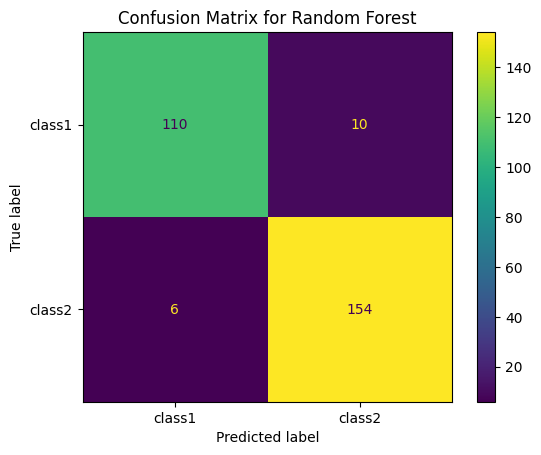

In [23]:
# Confusion matrix for Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["class1", "class2"])
disp.plot()
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [24]:
from sklearn import metrics

# Calculate actual and predicted labels for the test set
actual = y_test
predicted = best_rf_model.predict(X_test)

print("Classification Report for Random Forest:")
print(metrics.classification_report(actual, predicted, target_names=["class1", "class2"]))

print("\\nConfusion Matrix:")
print(metrics.confusion_matrix(actual, predicted))

Classification Report for Random Forest:
              precision    recall  f1-score   support

      class1       0.95      0.92      0.93       120
      class2       0.94      0.96      0.95       160

    accuracy                           0.94       280
   macro avg       0.94      0.94      0.94       280
weighted avg       0.94      0.94      0.94       280

\nConfusion Matrix:
[[110  10]
 [  6 154]]


In [25]:
from sklearn.svm import SVC
# SVM
# parameters you may consider
# C = [0.01, 0.1, 1, 5]
# gamma = [0.01, 0.1, 1, 10]
# optional
# kernel = []
param_grid_svm = {
    'C': [0.01, 0.1, 1, 5],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm = SVC(random_state=0)

grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

best_c_svm = grid_search_svm.best_params_['C']
best_gamma_svm = grid_search_svm.best_params_['gamma']
best_kernel_svm = grid_search_svm.best_params_['kernel']
cv_accuracy_svm = grid_search_svm.best_score_

best_svm_model = grid_search_svm.best_estimator_
test_accuracy_svm = best_svm_model.score(X_test, y_test)

print(f"SVM best C: {best_c_svm}")
print(f"SVM best gamma: {best_gamma_svm}")
print(f"SVM best kernel: {best_kernel_svm}")
print(f"SVM cross-validation accuracy: {cv_accuracy_svm:.4f}")
print(f"SVM test set accuracy: {test_accuracy_svm:.4f}")

SVM best C: 5
SVM best gamma: 1
SVM best kernel: rbf
SVM cross-validation accuracy: 0.9429
SVM test set accuracy: 0.9321


### Part 2: Results

Index(['Area', 'Perimiter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent'],
      dtype='object')


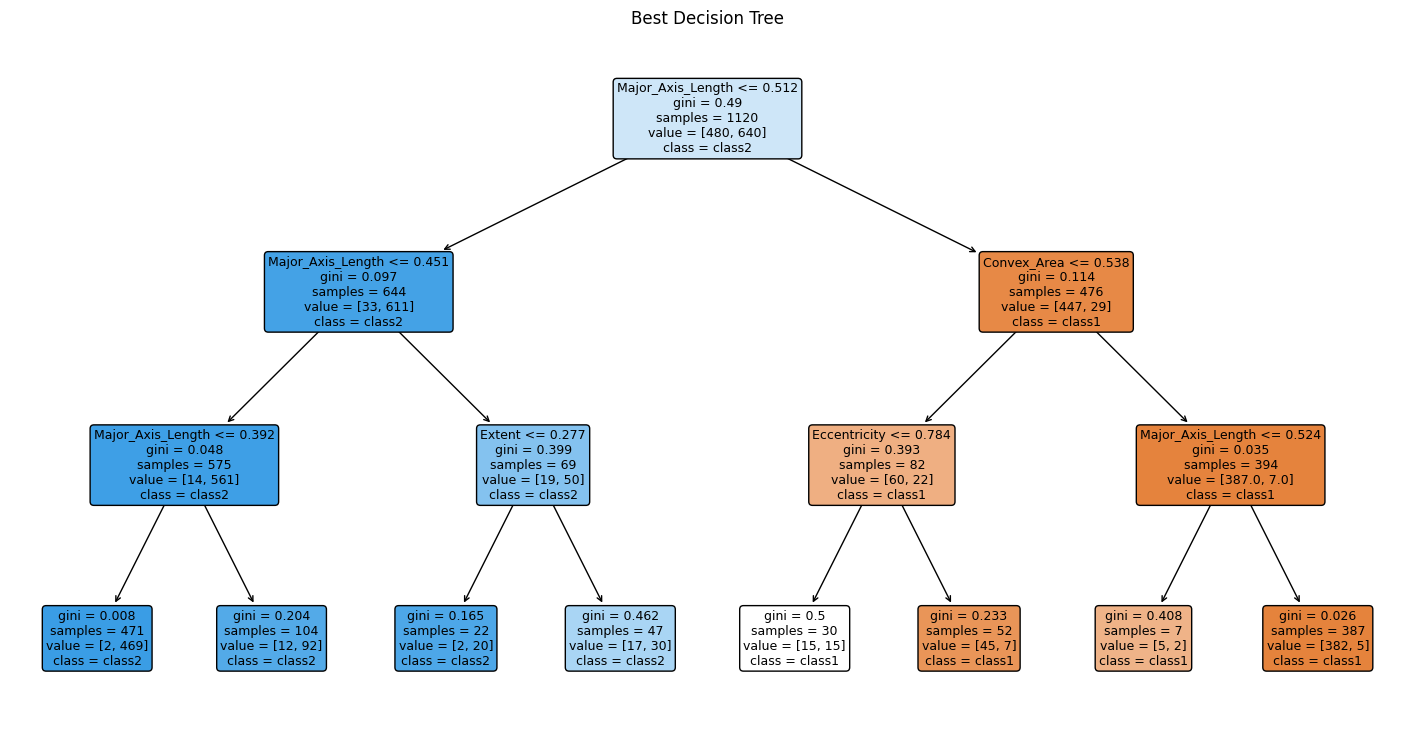

In [26]:
# graph for Best decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

print(feature_names)

plt.figure(figsize=(18, 9))
plot_tree(
    best_dt_model,
    filled=True,
    feature_names=feature_names,
    class_names=["class1", "class2"],
    rounded=True,
    fontsize=9
)
plt.title("Best Decision Tree")
plt.show()

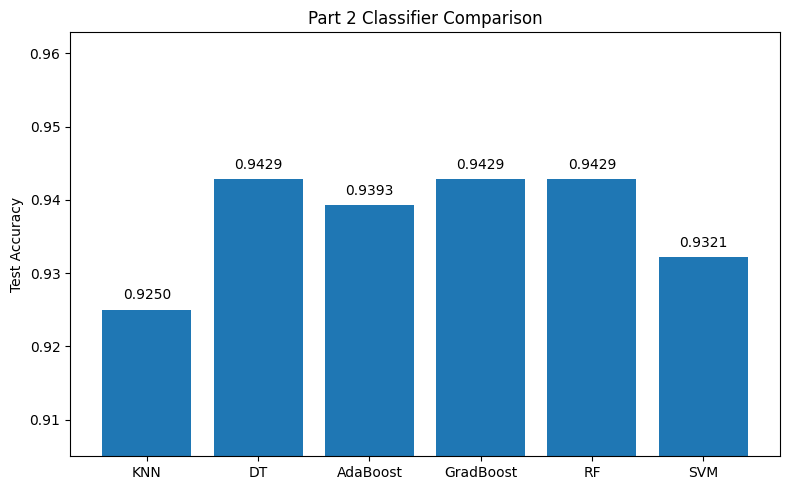

In [27]:
# graph for classifier comparison
import matplotlib.pyplot as plt

models = ["KNN", "DT", "AdaBoost", "GradBoost", "RF", "SVM"]
test_accuracies = [
    test_accuracy,
    test_accuracy_dt,
    test_accuracy_ada,
    test_accuracy_gb,
    test_accuracy_rf,
    test_accuracy_svm
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, test_accuracies)

ymin = min(test_accuracies) - 0.02
ymax = max(test_accuracies) + 0.02
plt.ylim(ymin, ymax)

# add exact values
for bar, val in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.001,
        f"{val:.4f}",
        ha="center",
        va="bottom"
    )
plt.ylabel("Test Accuracy")
plt.title("Part 2 Classifier Comparison")

plt.tight_layout()
plt.show()

### Test your code

In [28]:
#load the test dataset to test out your model 
df = pd.read_csv('test-before.csv')

## **3. Reflection and Discussion**



In this study, we evaluated the performance of the most common machine learning classifiers on a pre-processed rice dataset. After evaluation, all models have performed well, with the cross validation or test accuracies genearlly above 92%.\

**Baseline Models (Logistic Regression & Naïve Bayes):**\
The cross-validation accuracy of logistic regression is 0.9386, which exceeds the 0.9264 accuracy of Naive Bayes. The superior performance of logistic regression suggests that the normalized features share a relatively clear linear decision boundary, while the assumption of feature independence in Naive Bayes may not be fully consistent with this particular dataset.\

**Single Complex Models (KNN & Decision Tree):**\
The test accuracy of KNN is 0.9250. The single decision tree performed better, achieving 0.9429 test accuracy. The high accuracy of the single tree suggests that a simple, rule-based hierarchy is well suited for classifying these features and more effective for capturing the patterns in the dataset.\

**Ensemble Methods (AdaBoost, Gradient Boosting & Random Forest):**\
The ensemble algorithm exhibits great stability. AdaBoost, Gradient Boosting, and Random Forest all achieved a test accuracy of 0.9429. For random forest, the macro-average F1 score is 0.9414, and the weighted average F1 score is 0.9427, which shows significant agreement with the overall accuracy. This confirms that the random forest model consistently performs well in both categories without being biased towards the majority category.\

**Support Vector Machine (SVM):**\
Under the Radial Basis Function (RBF) kernel function, SVM achieves 0.9429 cross validation accuracy and 0.9321 final test accuracy. But it performs slightly lower on the test set compared to the tree-based model. This feature suggests that the nonlinear projection, while powerful, may capture slight noise unique to the training part.

The results show that all models performed well on the rice dataset, with most accuracies above 0.93. In Part 1, Logistic Regression achieved an average cross-validation accuracy of 0.9386, which is slightly higher than Naïve Bayes at 0.9264. This indicates that Logistic Regression is better suited to this dataset. A possible reason is that Naïve Bayes assumes independence between features, while the rice features are extracted from images and are likely to be correlated.

After applying hyperparameter tuning in Part 2, the performance of most models became both high and stable. AdaBoost achieved the highest cross-validation accuracy of 0.9455, followed closely by Gradient Boosting (0.9446) and SVM (0.9429). However, when evaluating on the test set, Decision Tree, AdaBoost, Gradient Boosting and Random Forest all reached the same accuracy of 0.9429. This suggests that several models are able to generalise equally well on unseen data.

KNN also produced competitive results, with a test accuracy of 0.9357. In contrast, SVM showed a slightly lower test accuracy of 0.9321 compared to its cross-validation accuracy. This difference may indicate a small level of overfitting or sensitivity to parameter selection.

The results also show that models with higher flexibility tend to perform better after tuning. Methods such as AdaBoost, Gradient Boosting and Random Forest are able to capture more complex relationships in the data. Ensemble methods in particular perform consistently well, as they combine multiple models and reduce variance.

For Random Forest, the macro-average F1 score is 0.9414 and the weighted-average F1 score is 0.9427. These values are very close to each other and also close to the test accuracy, which suggests that the model performs consistently across both classes. The small difference between the two F1 scores also indicates that class imbalance is not a major issue in this dataset.


The strong performance of most classifiers suggests that the dataset is relatively easy to separate after preprocessing. Many models achieved similar test accuracies around 0.94, which indicates that the features already provide clear information to distinguish the two classes.

Although ensemble methods such as AdaBoost, Gradient Boosting and Random Forest achieved slightly higher performance, the improvement over Logistic Regression is small (0.9429 vs 0.9386). This suggests that a simpler model like Logistic Regression may still be a reasonable choice when interpretability and efficiency are important.

## **AI Acknowledgement**